In [5]:
! uv add accelerate

Resolved 272 packages in 2.91s                                       
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq       ⠋ Preparing packages... (0/0)                                                   
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///Users/finn.krammer/Documents/shapiq[1A
   Building shapiq @ file:///U

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, PreTrainedTokenizerBase, PreTrainedModel
import torch
import torch.nn.functional as F

# Export "HF_TOKEN" in a .env file or manually.
# You will need to create a Huggingface token and accept Googles TOS for accessing gemma through HF.
# No need to use the token in the code, the model download will look for the environmental variable automatically.
from dotenv import load_dotenv
load_dotenv()

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using", device)
# For torch compile
if device=="cuda":
    import os
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    from transformers.cache_utils import HybridCache

from __future__ import annotations
import numpy as np
from shapiq.game import Game
from shapiq import ExactComputer, KernelSHAP

Using mps


In [77]:
MODEL = "google/gemma-2-2b-it"
EMBED_MODEL = "google/embeddinggemma-300m"

In [78]:
torch.manual_seed(1)

tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-2b-it")
model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    device_map=device,
    torch_dtype=torch.bfloat16
)

# Torch compile with cache.
# Setting past_key_values to None so that 
# outputs = model.generate(**input_ids, past_key_values=past_key_values)
# still works, even when not using the cache when not using cuda.
past_key_values = None
if device=="cuda":
    model.forward = torch.compile(
        model.forward,
        mode="reduce-overhead",
        fullgraph=True
    )

    past_key_values = HybridCache(
        config=model.config,
        max_batch_size=1,
        max_cache_len=model.config.max_position_embeddings,
        device=model.device,
        dtype=model.dtype
    )

    model._supports_cache_class = True
    model.generation_config.cache_implementation = None

    # Warming up the cache
    input_text = "The quick brown fox jumps over the lazy dog. " * 20
    model_inputs = tokenizer(input_text, return_tensors="pt").to(device)
    prompt_length = model_inputs.input_ids.shape[1]
    for idx in range(2):
        outputs = model.generate(**model_inputs, past_key_values=past_key_values, do_sample=True, temperature=1.0, max_new_tokens=128)
        past_key_values.reset()

Loading weights:   0%|          | 0/288 [00:01<?, ?it/s]

In [79]:
embed_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL)
embed_model = AutoModel.from_pretrained(
    EMBED_MODEL,
    device_map=device,
    torch_dtype=torch.bfloat16
)

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

In [93]:
"""This module contains the GraphGame for GraphSHAP-IQ."""
class LMGame(Game):
    """GraphSHAP-IQ explanation game for graph neural networks.

    The game evaluates a graph neural network on masked versions of a given
    input graph. Each node is treated as one player. For a coalition, nodes
    inside the coalition keep their original node features, while nodes outside
    the coalition are replaced by a baseline feature vector.

    The resulting model output defines the value of the coalition and can be
    used to compute Shapley interaction values for GraphSHAP-IQ.

    Attributes:
        model: The graph neural network used for prediction.
        x_graph: A cloned version of the input graph instance to explain.
        class_index: Output index to explain. If ``None``, the model output is
        expected to be scalar and is used directly.
        edge_index: The graph connectivity in COO format as a NumPy array.
        l_hop_distance: The number of message-passing layers of the GNN.
        n_players: The number of players in the game, equal to the number of
            nodes in ``x_graph``.
        grand_coalition_set: Set containing all node indices of the graph.
        baseline: Feature vector used to replace inactive node features.
        normalization_value: Value of the empty coalition used for
            normalization when ``normalize`` is enabled.
    """

    def __init__(
        self,
        model: PreTrainedModel,
        tokenizer: PreTrainedTokenizerBase,
        embed_model: PreTrainedModel,
        embed_tokenizer: PreTrainedTokenizerBase,
        sequence: str,
        *,
        baseline_id: int | None = None,
        sampling_params: dict | None = None,
        cache: HybridCache | None = None,
        normalize: bool = False,
        verbose: bool = False,
    ) -> None:
        """Initialize the graph explanation game.

        Args:
            model: Graph neural network to explain. The model must define a
                ``num_layers`` attribute indicating the number of message-passing
                layers.
            x_graph: Input graph instance to explain. The graph must contain node
                features in ``x_graph.x`` and an ``edge_index`` attribute.
            class_index: Output index to explain for multi-output models. If ``None``, the model
                output is expected to be scalar and is used directly.
            baseline_strategy: Strategy used to compute the baseline feature vector for
                inactive nodes. Supported values are ``"zeros"``, ``"average"``,
                ``"min"``, and ``"max"``.
            baseline_value: Explicit baseline used for inactive node features. If
                provided, this overrides ``baseline_strategy``. A float creates a
                constant baseline vector, while a tensor specifies one baseline value
                per node feature.
            normalize: Whether to normalize the game by subtracting the empty
                coalition value.
            verbose: Whether to print progress information inherited from
                :class:`shapiq.game.Game`.

        Raises:
            AttributeError: If ``model`` does not define ``num_layers``.
            TypeError: If ``model.num_layers`` is not an integer.
            NotImplementedError: If ``baseline_strategy`` is unsupported.
        """
        self.sequence = sequence

        if len(self.sequence) == 0:
            msg = "Sequence must not be empty."
            raise ValueError(msg)

        self.device = next(model.parameters()).device

        self.model = model
        self.model.eval().to(device)
        self.sampling_params = sampling_params
        self.cache = cache
        self.tokenizer = tokenizer
        self.embed_model = embed_model
        self.embed_model.eval().to(device)
        self.embed_tokenizer = embed_tokenizer
        self.special_token_ids = self.tokenizer.all_special_ids
        self.n_players = len(self.tokenizer.encode(self.sequence, add_special_tokens=False))

        if baseline_id is not None:
            self.baseline = baseline_id
        else:
            self.baseline = tokenizer.encode(" ", add_special_tokens=False)[0]

        if normalize:
            empty_coalition_value = self.value_function(np.zeros(self.n_players))
            normalization_value = float(empty_coalition_value[0])
            super().__init__(
                n_players=self.n_players,
                normalize=normalize,
                normalization_value=normalization_value,
                verbose=verbose,
            )
        else:
            super().__init__(n_players=self.n_players, normalize=normalize, verbose=verbose)

        if normalize:
            self.normalization_value = normalization_value

    @property
    def normalize(self) -> bool:
        """Override the normalize property to return the actual normalize flag."""
        return self._normalize

    def mask_input(self, coalition: np.ndarray):
        """Create a masked graph for a coalition.

        Args:
            coalition: Boolean or binary array of shape ``(n_players,)`` indicating
                which nodes are active.

        Returns:
            A cloned graph where inactive node features are replaced by the
            baseline feature vector.
        """
        if len(coalition) != self.n_players:
            msg = "Coalition must be the same size as number of non-special tokens."
            raise ValueError(msg)
        sequence_masked = self.tokenizer(self.sequence, return_tensors="pt").to(self.device)
        c = 0
        for s, token_id in enumerate(sequence_masked.input_ids[0]):
            # Skip special tokens
            if token_id in self.special_token_ids:
                pass
            else:
                if not coalition[c]:
                    sequence_masked.input_ids[0][s] = self.baseline
                c += 1
        return sequence_masked

    def value_function(self, coalitions: np.ndarray) -> np.ndarray:
        """Evaluate coalition values by running the GNN on masked graphs.

        Args:
            coalitions: Boolean or binary coalition matrix of shape
                ``(n_coalitions, n_players)``. A one-dimensional array of shape
                ``(n_players,)`` is interpreted as a single coalition.

        Returns:
            One-dimensional NumPy array with one scalar model output per coalition.
            For classification, the selected class logit is returned. For
            regression, the scalar model output is returned.
        """
        baseline_sequence = self.mask_input(torch.ones(self.n_players))
        # print(self.tokenizer.convert_ids_to_tokens(baseline_sequence["input_ids"][0], skip_special_tokens=False))
        baseline_output = self.model_generate(baseline_sequence)
        # print(baseline_output)
        baseline_embed = self.embed(baseline_output)
        
        if coalitions.ndim == 1:
            coalitions = coalitions.reshape(1, -1)

        coalition_values = []

        for coalition in coalitions:
            sequence_masked = self.mask_input(coalition)
            # print(self.tokenizer.convert_ids_to_tokens(sequence_masked["input_ids"][0], skip_special_tokens=False))
            model_output = self.model_generate(sequence_masked)
            # print(model_output)
            # Calculate Value
            output_embed = self.embed(model_output)
            coalition_value = self.similarity(baseline_embed, output_embed)
            coalition_values.append(coalition_value.item())
        return np.array(coalition_values)
    
    def embed(self, text, prompt="task: sentence similarity | query: "):
        inputs = self.embed_tokenizer(prompt + text, return_tensors="pt").to(self.device)
        with torch.no_grad():
            hidden = self.embed_model(**inputs).last_hidden_state
        emb = hidden.mean(dim=1).float()
        return F.normalize(emb, dim=-1)[0]

    def similarity(self, e1, e2):
        return F.cosine_similarity(e1, e2, dim=0)

    def model_generate(self, input):
        with torch.no_grad():
            if self.sampling_params is None:
                model_output = self.model.generate(**input,
                    past_key_values=self.cache,
                    max_new_tokens=256,
                    do_sample=False
                )
            else:
                model_output = self.model.generate(**input,
                    past_key_values=self.cache,
                    **self.sampling_params
                )
            if self.cache is not None:
                self.cache.reset()
        model_output = self.tokenizer.decode(model_output[0], skip_special_tokens=True)
        return model_output

In [ ]:
game = LMGame(
        model=model,
        tokenizer=tokenizer,
        embed_model=embed_model,
        embed_tokenizer=embed_tokenizer,
        sequence="Who is Biden?",
        verbose=True
)

Evaluating game:   0%|          | 0/16 [00:00<?, ? coalition/s]

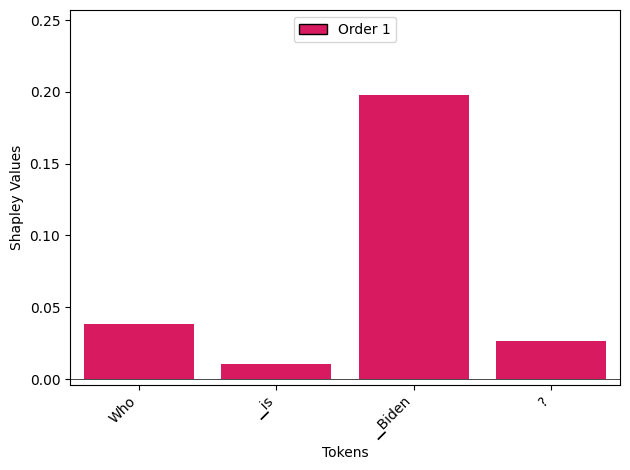

In [90]:
exact_computer = ExactComputer(n_players=game.n_players, game=game)
sv_exact = exact_computer(index="SV")

token_ids = game.tokenizer.encode(game.sequence)
tokens = game.tokenizer.convert_ids_to_tokens(token_ids, skip_special_tokens=True)

sv_exact.plot_stacked_bar(
    xlabel="Tokens",
    ylabel="Shapley Values",
    feature_names=tokens,
)

In [ ]:
approx = KernelSHAP(n=game.n_players, random_state=1)
sv_approx = approx.approximate(budget=50, game=game)
sv_approx.plot_stacked_bar(
    xlabel="Tokens",
    ylabel="Shapley Values",
    feature_names=tokens,
)